In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
paths = {
    8: '../training/runs/sweeps/sigma8.0',
    4: '../training/runs/sweeps/sigma4.0',
    2: '../training/runs/sweeps/sigma2.0',
    1: '../training/runs/sweeps/sigma1.0',
}

models = {}
for sigma, path in paths.items():
    model = load_model_from_config(path, dataloaders, device)
    models[sigma] = model

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
from sensorium.utility.scores import get_correlations

for sigma, model in models.items():
    print(f'{sigma}: {get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)}')

8: 0.40774816274642944
4: 0.4075814187526703
2: 0.40841081738471985
1: 0.40875935554504395


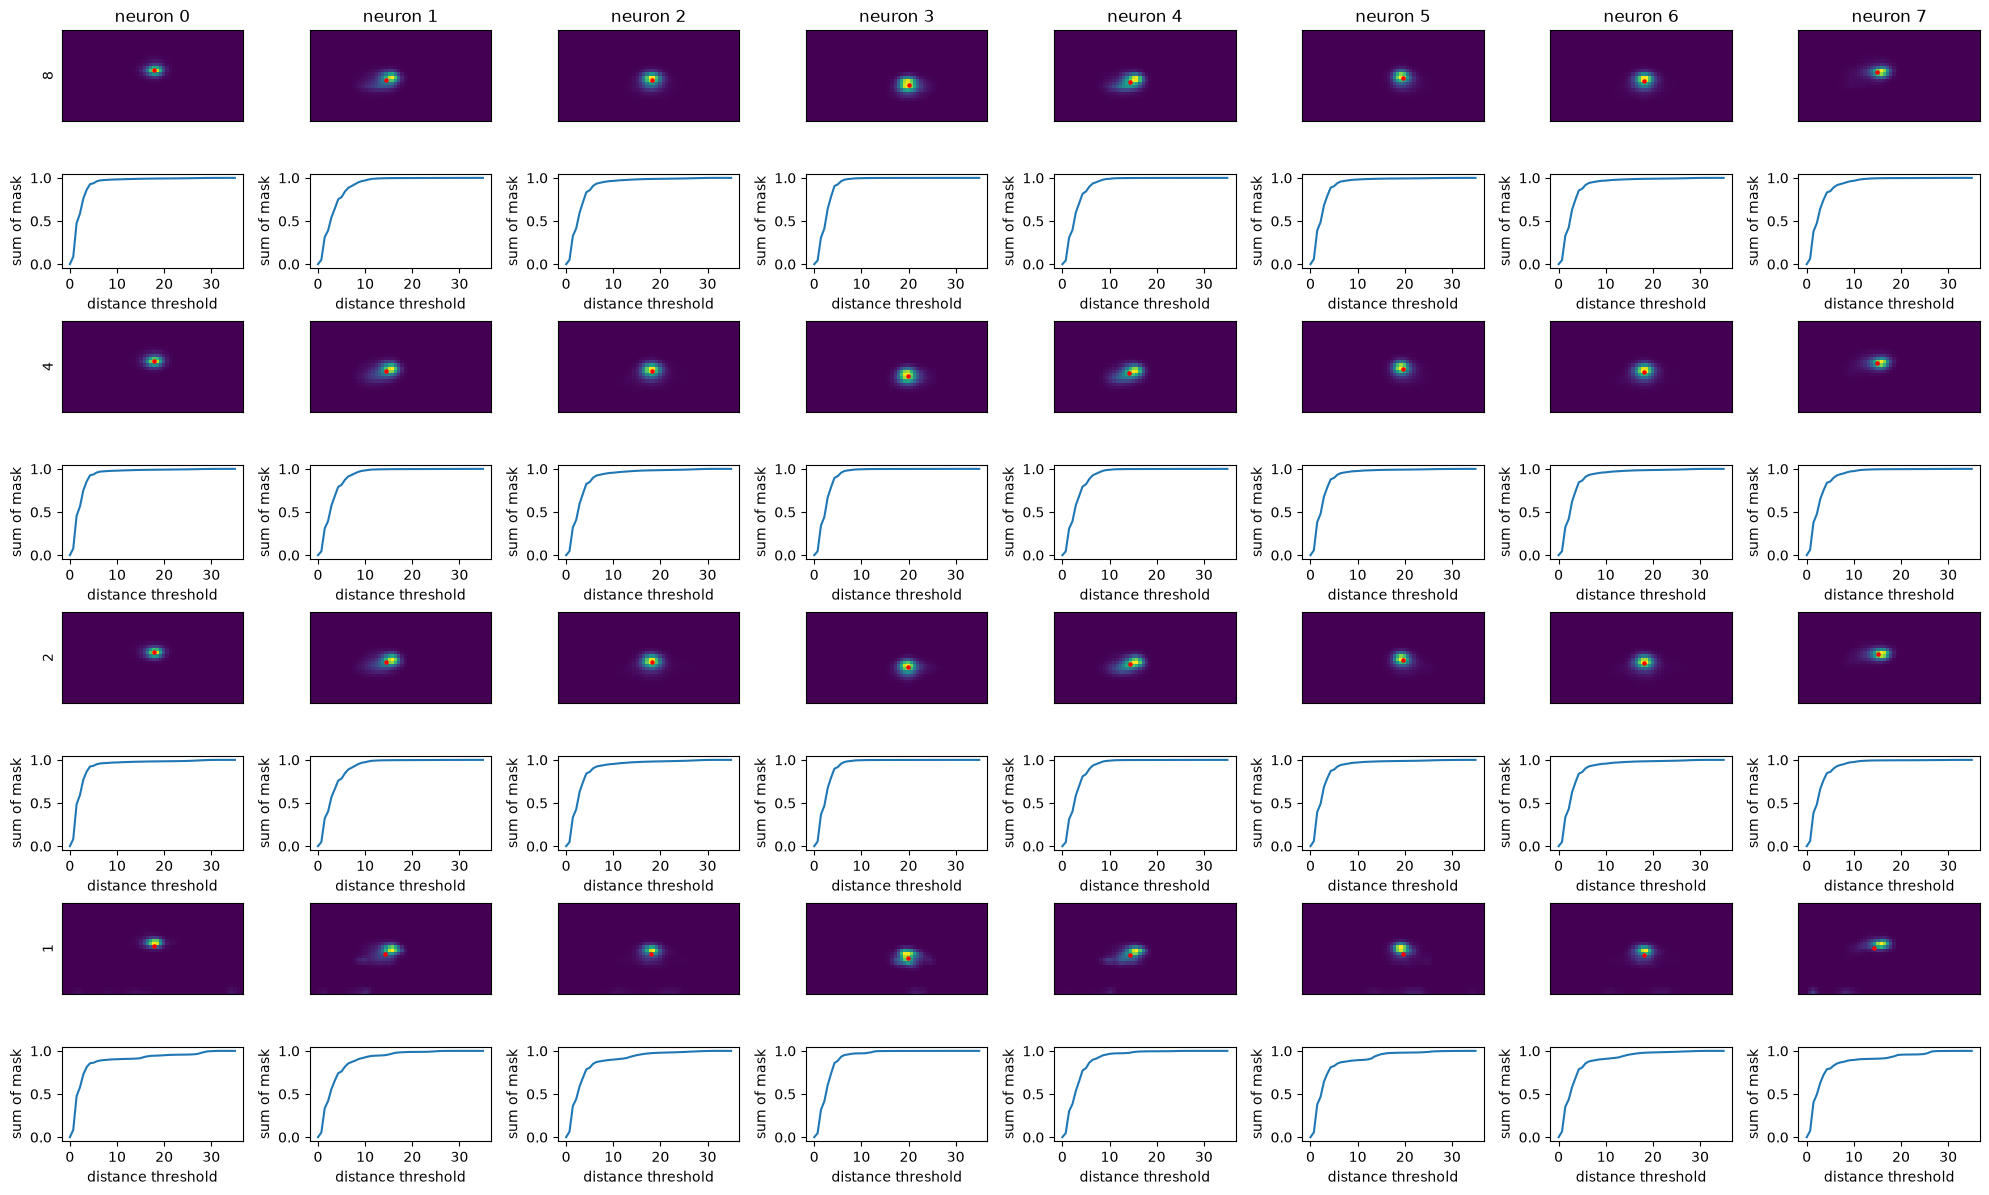

In [4]:
n = 8
fig, axs = plt.subplots(len(models) * 2, n, figsize=(20, 12))
neurons = None

for i, (sigma, model) in enumerate(models.items()):    
    spatials = torch.cat([model.readout[k].spatial.detach().cpu() for k in [data_keys[6]]])
    neurons = torch.randperm(spatials.shape[0])[:n] if neurons is None else neurons
    for j in range(n):
        ax = axs[i * 2][j]
        spatial = spatials[neurons[j]]

        h, w = spatial.shape
        y = spatial.sum(dim=1)  # h
        x = spatial.sum(dim=0)  # w

        y_pos = torch.arange(h)
        x_pos = torch.arange(w)

        y_avg = (y_pos * y).sum()
        x_avg = (x_pos * x).sum()

        ax.imshow(spatial)
        ax.scatter(x_avg, y_avg, s=5, color='red')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f'neuron {j}')
        if j == 0:
            ax.set_ylabel(sigma)

        y_max = y.argmax()
        x_max = x.argmax()

        y_dist = (y_pos - y_max).pow(2)
        x_dist = (x_pos - x_max).pow(2)

        yy, xx = torch.meshgrid(y_dist, x_dist, indexing='ij')
        dists = torch.stack([xx, yy], dim=-1).sum(-1).sqrt()

        thresholds = torch.linspace(0, 35, steps=50)
        volumes = []
        for t in thresholds:
            vol = spatial[dists < t].sum()
            volumes.append(vol)
        
        ax = axs[i * 2 + 1][j]
        ax.plot(thresholds, volumes)
        ax.set_xlabel('distance threshold')
        ax.set_ylabel('sum of mask')

plt.tight_layout()

In [5]:
full_grids = {}
for sigma, model in models.items():
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grids.append(grid)

    full_grids[sigma] = grids

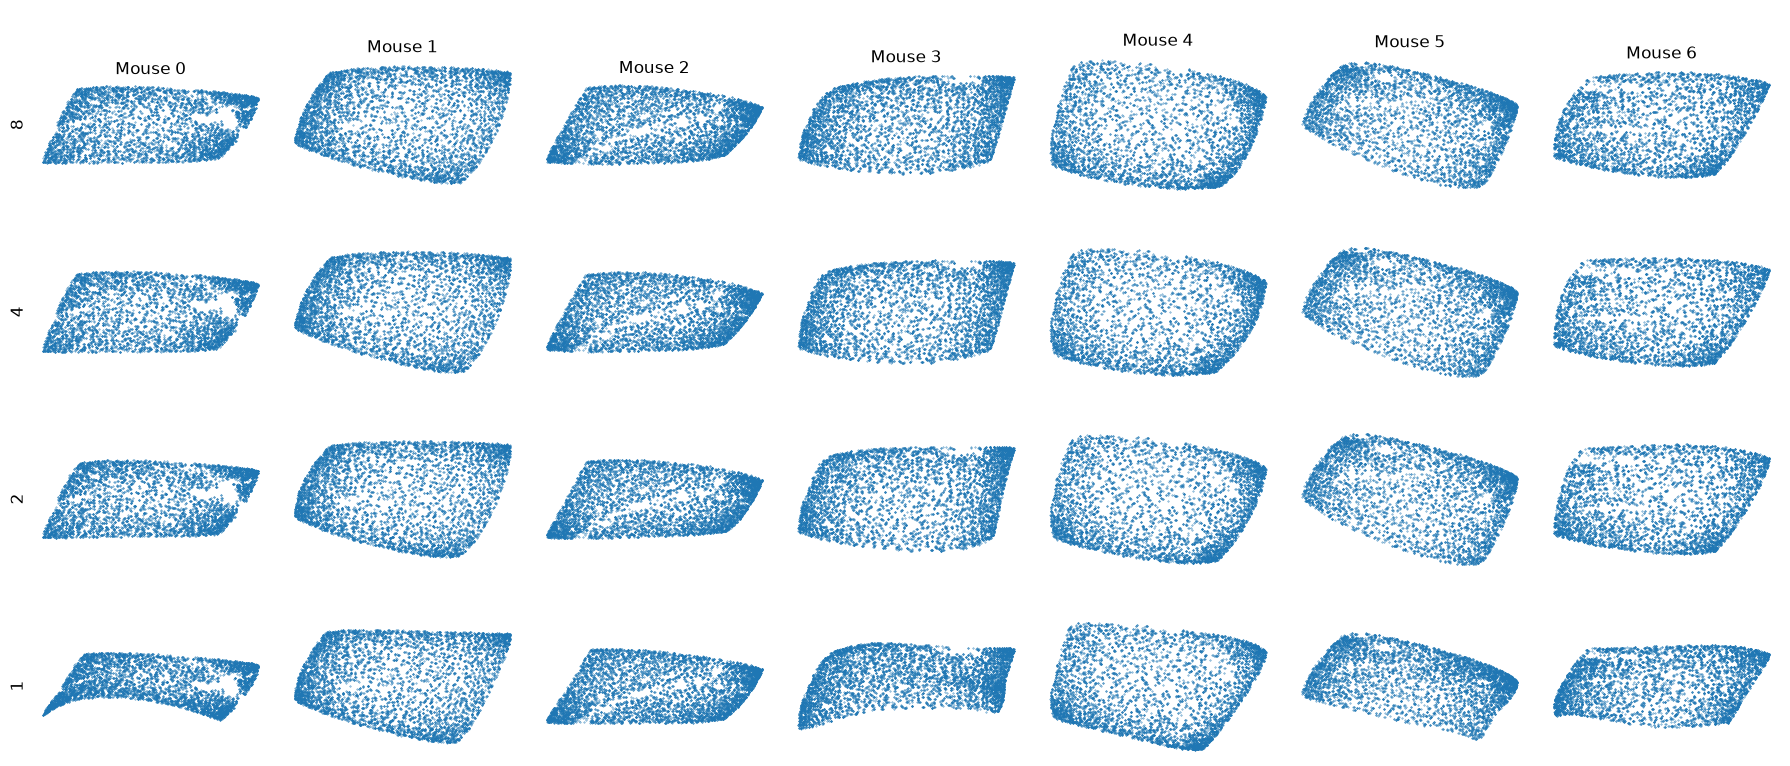

In [6]:
model_seeds = [0, 42, 123]
model_types = full_grids

num_mice = 7
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 8))

for row_idx, (type_name, grids) in enumerate(model_types.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx]
        grid = grids[mouse_idx]
        ax.scatter(
            grid[:, 0], grid[:, 1],
            alpha=1, s=0.1,
        )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # column labels on top row only
        if row_idx == 0:
            ax.set_title(f"Mouse {mouse_idx}")

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')

# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 1.0),
    markerscale=40,
    frameon=False,
)

plt.tight_layout()
plt.show()

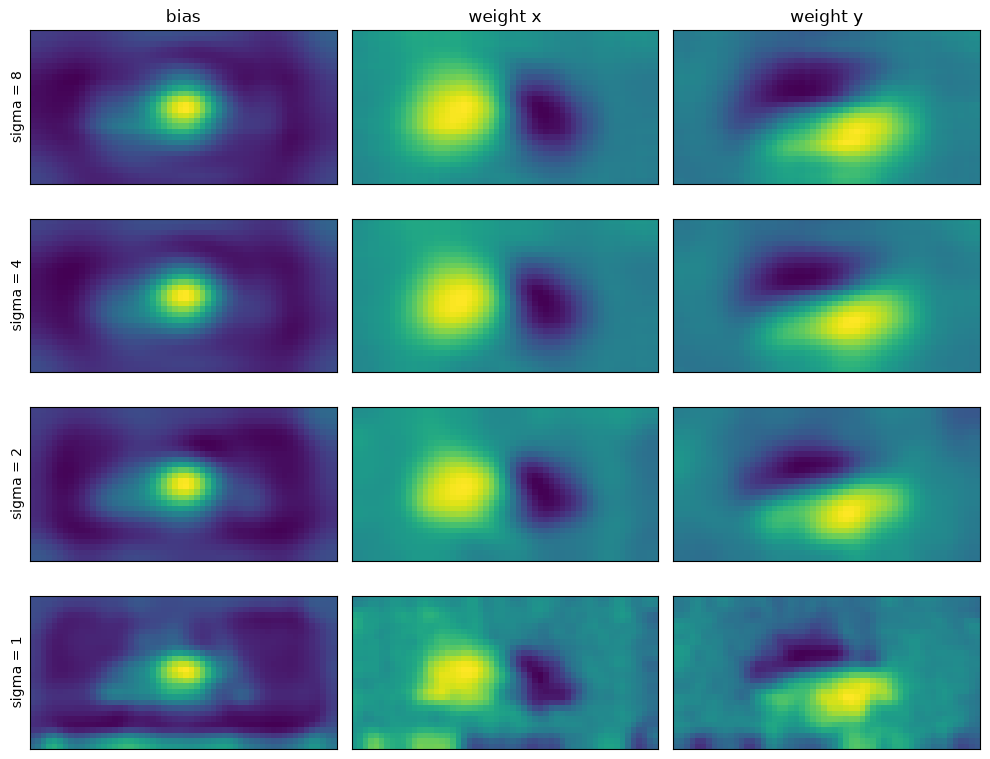

In [64]:
fig, axs = plt.subplots(4, 3, figsize=(10, 8))
for i, (sigma, model) in enumerate(models.items()):
    readout = model.readout[data_keys[6]].to('cpu')
    kernel = readout.gaussian_kernel('cpu')
    bias = readout.smooth(readout.spatial_b, kernel).detach()
    weight = readout.smooth(readout.spatial_w, kernel).detach()
    
    axs[i][0].imshow(bias[0])
    axs[i][0].set_xticks([])
    axs[i][0].set_yticks([])
    axs[i][0].set_ylabel(f'sigma = {sigma}')

    axs[i][1].imshow(weight[1])
    axs[i][1].set_xticks([])
    axs[i][1].set_yticks([])
    
    axs[i][2].imshow(weight[0])
    axs[i][2].set_xticks([])
    axs[i][2].set_yticks([])

    if i == 0:
        axs[i][0].set_title(f'bias')
        axs[i][1].set_title(f'weight x')
        axs[i][2].set_title(f'weight y')

plt.tight_layout()
plt.show()

In [76]:
kernel.min(), kernel.max()

(tensor(0.0067), tensor(0.0181))

In [71]:
h, w = 28, 56
logits = torch.randn(1, h, w)
out = torch.nn.functional.softmax(logits.view(1, h * w), dim=1).view(1, h, w)

In [75]:
(out + 1e-5).log()

tensor([[[ -6.9842,  -7.4152,  -7.6388,  ...,  -5.9719,  -7.9518,  -7.6300],
         [ -7.0229,  -9.5429,  -8.6424,  ...,  -6.7719,  -7.3840,  -8.8880],
         [ -8.7150,  -7.2379,  -7.8141,  ...,  -8.4719,  -7.6178,  -8.0863],
         ...,
         [ -7.5960,  -8.2001,  -7.8672,  ...,  -7.6957,  -7.6761,  -8.5284],
         [ -6.6384,  -8.5533,  -5.9712,  ...,  -8.2127,  -7.1654, -10.4475],
         [ -7.5537,  -8.3000,  -5.5681,  ...,  -7.4677,  -8.2653,  -8.3764]]])